# Objetivo do experimento

O objetivo deste experimento é avaliar o comportamento inicial do Algoritmo Genético (GA) aplicado à otimização de hiperparâmetros de uma rede neural MLP, utilizando uma configuração conservadora, com baixo custo computacional.

Busca-se observar:

- Convergência do algoritmo

- Estabilidade do fitness ao longo das gerações

- Capacidade de exploração do espaço de busca

## Configuração do Algoritmo Genético

A configuração adotada neste experimento foi:

Experimento 1 – Baseline GA (conservador)

Tamanho da população: 5

Gerações: 10

Taxa de mutação: 0.1

Taxa de cruzamento: 0.8

Elitism: 1

Tamanho de torneio: 2

## Justificativa das escolhas:

Population size = 5
Valor reduzido para controlar o custo computacional do treinamento de MLPs.

Elitismo = 1
Garante a preservação da melhor solução encontrada a cada geração.

Tournament size = 2
Pressão seletiva moderada.

Crossover rate = 0.8
Favorece recombinação genética.

Mutation rate = 0.1
Estratégia conservadora para evitar perturbações excessivas.

Random seed = 42
Permite reprodutibilidade dos resultados.

## Execução do experimento

In [1]:

from fase_2.ga.ga_runner import run_ga

config = {
    "population_size": 5,
    "generations": 10,
    "mutation_rate": 0.1,
    "crossover_rate": 0.8,
    "elite_size": 1,
    "tournament_size": 2,
    "random_seed": 1
}

result = run_ga(config)
result

/Users/jhonatan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/jhonatan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/jhonatan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/jhonatan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/jhonatan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/jhonatan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/jhonatan/Library/Python/3.9/lib/python/site-packages/sklearn/util

{'best_fitness': 0.7209705372616985,
 'best_individual': {'n_hidden_layers': 2,
  'n_neurons': 16,
  'learning_rate_init': 0.001,
  'activation': 'tanh'},
 'fitness_history': [0.7209705372616985,
  0.7209705372616985,
  0.7209705372616985,
  0.7209705372616985,
  0.7209705372616985,
  0.7209705372616985,
  0.7209705372616985,
  0.7209705372616985,
  0.7209705372616985,
  0.7209705372616985]}

## Resultados obtidos

Melhor indivíduo encontrado

In [2]:
result["best_individual"]

{'n_hidden_layers': 2,
 'n_neurons': 16,
 'learning_rate_init': 0.001,
 'activation': 'tanh'}

## Melhor valor de fitness (F1-score)

In [3]:
result["best_fitness"]

0.7209705372616985

## Evolução do fitness ao longo das gerações

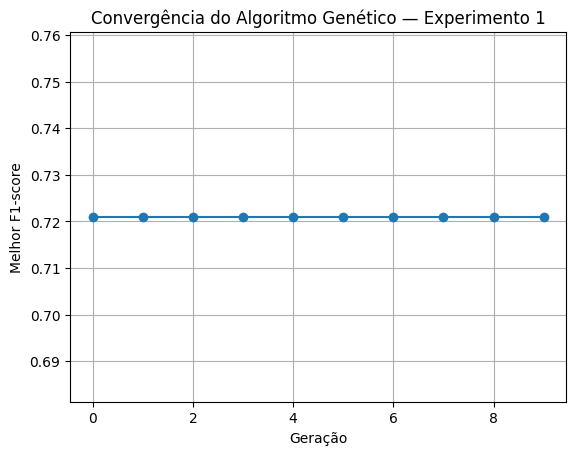

In [4]:
import matplotlib.pyplot as plt

plt.plot(result["fitness_history"], marker='o')
plt.xlabel("Geração")
plt.ylabel("Melhor F1-score")
plt.title("Convergência do Algoritmo Genético — Experimento 1")
plt.grid(True)
plt.show()

## Análise dos resultados

Observa-se que o Algoritmo Genético converge rapidamente para um valor de F1-score em torno de 0.72, mantendo-se estável ao longo das gerações subsequentes.

Essa estabilidade indica que:

O espaço de busca é relativamente pequeno;

A configuração conservadora favorece rápida convergência;

A diversidade genética é reduzida após poucas gerações;

O algoritmo encontra rapidamente um ótimo local (ou global).

## Comparativo com o modelo treinado sem otimização (Tech challenge fase 1)

In [6]:
from utils.module_diabetes import load_dataset, prepare_dataset, train_mlp
from fase_2.ga.fitness import calculate_fitness

baseline_params = {
    "hidden_layer_sizes": (16, 8)
}

df = load_dataset()
df_processed = prepare_dataset(df)
model, X_val, y_val = train_mlp(df_processed, baseline_params)
baseline_f1 = calculate_fitness(model, X_val, y_val)

baseline_f1

/Users/jhonatan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/jhonatan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/jhonatan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/jhonatan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/jhonatan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/jhonatan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


0.7164351851851852

In [9]:
import pandas as pd

pd.DataFrame({
    "Modelo": ["Baseline", "GA - Experimento 1"],
    "F1-score": [baseline_f1, result["best_fitness"]]
})


,Modelo,F1-score
0,Baseline,0.716435
1,GA - Experimento 1,0.720971


## Conclusão do Experimento 1

Comparando os resultados obtidos pelo Algoritmo Genético com o modelo treinado no projeto da Fase 1, observa-se que o F1-score da classe positiva permaneceu em torno de 0.72 em ambos os casos.

Esse resultado indica que, para a configuração conservadora adotada no Experimento 1, o Algoritmo Genético foi capaz de encontrar soluções equivalentes ao modelo baseline, porém sem apresentar ganho significativo de desempenho.

Tal comportamento era esperado devido ao espaço de busca reduzido e à baixa taxa de mutação, que favorecem rápida convergência em detrimento da exploração do espaço de soluções.

O Experimento 1 demonstra que:

O Algoritmo Genético é capaz de encontrar boas configurações de hiperparâmetros para a MLP;

Configurações conservadoras são eficazes em termos de custo computacional;

No entanto, apresentam limitação na exploração do espaço de busca.

Esses resultados motivam a realização de experimentos adicionais com configurações mais exploratórias, aumentando população, mutação e diversidade genética.